# Early Stopping Behavior Analysis

Analyzes early stopping convergence across basins and modes (Daily, MTS).

**Current ES config (all basins):**
- `early_stopping: True`, mode: `patience`
- `patience_early_stopping: 5` (5 bad validation checks → stop)
- `validate_every: 3` → effective tolerance: 15 epochs of no improvement
- `min_delta_early_stopping: 0.0` (any improvement resets counter)
- `minimum_epochs_before_early_stopping: 16`
- Loss function: `MaskedNSELoss` (variance-normalized squared error)
- Optimizer: Adam + fixed LR schedule

**Key question:** Is ES actually triggering? If not, what settings would make it trigger at the right time?

In [1]:
import sys
sys.path.insert(0, "../..")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from UCB_training.UCB_plotting import analyze_early_stopping_runs, extract_losses_from_tensorboard

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [2]:
# ── Utility Functions ─────────────────────────────────────────────

def load_es_state(pt_path):
    """Load early_stopper_state .pt file, return dict with history."""
    return torch.load(pt_path, map_location='cpu', weights_only=False)


def collect_es_states(runs_root, grid_pattern="CROSS_VAL_*_grid_*"):
    """Collect all early_stopper_state files from a CV grid run.
    Returns list of dicts: {grid, fold, state, path}.
    """
    results = []
    for grid_dir in sorted(Path(runs_root).glob(grid_pattern)):
        grid_name = grid_dir.name
        for pt_file in sorted(grid_dir.rglob("early_stopper_state_epoch*.pt")):
            fold_part = [p for p in pt_file.parts if p.startswith("fold_")]
            fold = fold_part[0] if fold_part else "unknown"
            state = load_es_state(pt_file)
            results.append({
                'grid': grid_name,
                'fold': fold,
                'state': state,
                'path': pt_file,
                'final_epoch': int(pt_file.stem.split('epoch')[-1]),
            })
    return results


def extract_loss_history(state):
    """Extract (epochs, losses) arrays from an ES state dict."""
    history = state.get('history', [])
    if not history:
        return np.array([]), np.array([])
    epochs, losses = zip(*history)
    return np.array(epochs), np.array(losses)


def compute_bad_check_runs(epochs, losses, min_delta=0.0, min_epoch=16):
    """Simulate patience counter for a loss history.
    Returns list of consecutive bad-check run lengths.
    """
    best_loss = float('inf')
    bad_checks = 0
    runs = []  # lengths of consecutive bad-check streaks
    current_run = 0
    
    for ep, loss in zip(epochs, losses):
        if ep < min_epoch:
            best_loss = min(best_loss, loss)
            continue
        if loss < best_loss - min_delta:
            best_loss = loss
            if current_run > 0:
                runs.append(current_run)
            current_run = 0
        else:
            current_run += 1
    if current_run > 0:
        runs.append(current_run)
    return runs


def simulate_early_stop(epochs, losses, patience=5, min_delta=0.0, min_epoch=16):
    """Simulate ES with given params. Returns stop_epoch or None."""
    best_loss = float('inf')
    bad_checks = 0
    
    for ep, loss in zip(epochs, losses):
        if ep < min_epoch:
            best_loss = min(best_loss, loss)
            continue
        if loss < best_loss - min_delta:
            best_loss = loss
            bad_checks = 0
        else:
            bad_checks += 1
            if bad_checks >= patience:
                return ep
    return None


def load_tb_losses(run_dir):
    """Load train + validation losses from TensorBoard events in a run dir."""
    run_dir = Path(run_dir)
    # Find the NH run directory (testing_run_*) inside fold dir
    nh_dirs = sorted(run_dir.glob("testing_run_*"))
    if nh_dirs:
        run_dir = nh_dirs[-1]
    return extract_losses_from_tensorboard(run_dir)


print("Utility functions loaded.")

Utility functions loaded.


---
## 1. Calpella Daily: BASELINE vs ES_PATIENCE

Old experiment comparing fixed-epoch training (16/32/48) vs patience-based ES (patience=3, min_epochs=10).

In [3]:
CALP_DAILY_RUNS = Path("../../outputs/calpella/daily_shared/runs")
CALP_ES_RUNS = CALP_DAILY_RUNS / "ES_PATIENCE"

if CALP_ES_RUNS.exists():
    es_stats = analyze_early_stopping_runs(CALP_ES_RUNS)

    print(f"Total runs: {es_stats['total_runs']}")
    print(f"Early stopped: {es_stats['early_stopped_count']} ({es_stats['early_stopped_pct']:.1f}%)")
    print()
    for max_ep, stats in es_stats['by_max_epochs'].items():
        print(f"  max_epochs={max_ep}: {stats['runs']} runs, "
              f"{stats['early_stopped']} stopped ({stats['pct']:.1f}%)")
        if stats['stopped_at_epochs']:
            print(f"    stopped at: {stats['stopped_at_epochs']}")
else:
    print(f"ES_PATIENCE runs not found at {CALP_ES_RUNS}")

Total runs: 112
Early stopped: 44 (39.3%)

  max_epochs=16: 40 runs, 0 stopped (0.0%)
  max_epochs=32: 36 runs, 12 stopped (33.3%)
    stopped at: [25, 30]
  max_epochs=48: 36 runs, 32 stopped (88.9%)
    stopped at: [25, 30, 35, 40, 45]


---
## 2. MTS CV Grid Search — ES Convergence Analysis

Current config: 100 max epochs, patience=5, validate_every=3, min_delta=0.0.

**Hypothesis:** With Adam optimizer and min_delta=0.0, the loss grinds down indefinitely by negligible amounts, so ES patience never fires.

In [4]:
# ── Basin run directories ──
# Update stamps as new runs complete

MTS_RUNS = {
    'guerneville': Path('../../outputs/guerneville/mts_shared/runs'),
    'calpella': Path('../../outputs/calpella/mts_shared/runs'),
    'hopland': Path('../../outputs/hopland/mts_shared/runs'),
    'warm_springs': Path('../../outputs/warm_springs/mts_shared/runs'),
}

# Show what CROSS_VAL runs exist
for basin, runs_dir in MTS_RUNS.items():
    cv_dirs = sorted(runs_dir.glob("CROSS_VAL_*_grid_*")) if runs_dir.exists() else []
    if cv_dirs:
        grids = set(d.name.rsplit('_grid_', 1)[0] for d in cv_dirs)
        n_grids = len(cv_dirs)
        print(f"{basin:15s}: {n_grids} grid dirs — {', '.join(sorted(grids))}")
    else:
        print(f"{basin:15s}: no CROSS_VAL runs yet")

guerneville    : 8 grid dirs — CROSS_VAL_20260213T174057Z, CROSS_VAL_20260213T174057Z_phys
calpella       : no CROSS_VAL runs yet
hopland        : no CROSS_VAL runs yet
warm_springs   : no CROSS_VAL runs yet


### 2a. Load ES States — All Basins

In [5]:
all_es = {}

for basin, runs_dir in MTS_RUNS.items():
    states = collect_es_states(runs_dir)
    if states:
        all_es[basin] = states
        epochs_hit = [s['final_epoch'] for s in states]
        print(f"{basin}: {len(states)} folds loaded, "
              f"final epochs: {sorted(set(epochs_hit))}")

if not all_es:
    print("No ES state files found.")

guerneville: 24 folds loaded, final epochs: [100]


### 2b. Validation Loss Trajectories

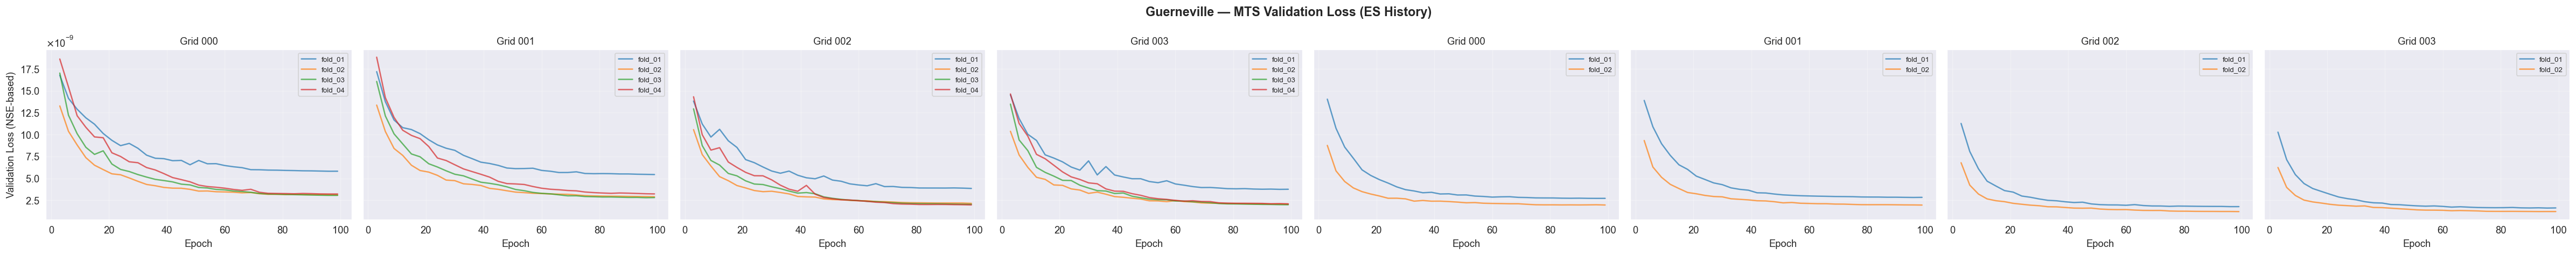

In [6]:
for basin, states in all_es.items():
    n = len(states)
    grids = sorted(set(s['grid'] for s in states))
    n_grids = len(grids)
    
    fig, axes = plt.subplots(1, n_grids, figsize=(5 * n_grids, 4), sharey=True, squeeze=False)
    fig.suptitle(f"{basin.replace('_', ' ').title()} — MTS Validation Loss (ES History)",
                 fontsize=14, fontweight='bold')
    
    for ax, grid_name in zip(axes[0], grids):
        grid_states = [s for s in states if s['grid'] == grid_name]
        grid_label = grid_name.split('_grid_')[-1]
        
        for s in grid_states:
            epochs, losses = extract_loss_history(s['state'])
            if len(epochs) > 0:
                ax.plot(epochs, losses, alpha=0.7, linewidth=1.5, label=s['fold'])
        
        ax.set_title(f"Grid {grid_label}", fontsize=11)
        ax.set_xlabel("Epoch")
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(axis='y', style='scientific', scilimits=(-9, -9))
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    axes[0][0].set_ylabel("Validation Loss (NSE-based)")
    plt.tight_layout()
    plt.show()

### 2c. Bad-Check Streak Analysis

With `min_delta=0.0`, how close did ES ever get to firing? Max consecutive bad checks needed to trigger: **5**.

In [7]:
for basin, states in all_es.items():
    print(f"\n{'='*60}")
    print(f"{basin.upper()} — Max consecutive bad checks (patience=5 needed to stop)")
    print(f"{'='*60}")
    
    all_max_runs = []
    
    for s in states:
        epochs, losses = extract_loss_history(s['state'])
        if len(epochs) == 0:
            continue
        
        runs = compute_bad_check_runs(epochs, losses, min_delta=0.0, min_epoch=16)
        max_run = max(runs) if runs else 0
        all_max_runs.append(max_run)
        
        grid_label = s['grid'].split('_grid_')[-1]
        print(f"  grid_{grid_label}/{s['fold']}: "
              f"max streak = {max_run}, "
              f"all streaks = {runs}")
    
    if all_max_runs:
        print(f"\n  Summary: max bad-check streak across all folds = {max(all_max_runs)} "
              f"(need 5 to stop)")
        print(f"  Mean max streak: {np.mean(all_max_runs):.1f}")


GUERNEVILLE — Max consecutive bad checks (patience=5 needed to stop)
  grid_000/fold_01: max streak = 3, all streaks = [1, 1, 3, 1]
  grid_000/fold_02: max streak = 1, all streaks = [1, 1, 1, 1, 1]
  grid_000/fold_03: max streak = 1, all streaks = [1, 1]
  grid_000/fold_04: max streak = 2, all streaks = [1, 2, 1]
  grid_001/fold_01: max streak = 2, all streaks = [2, 2, 2]
  grid_001/fold_02: max streak = 0, all streaks = []
  grid_001/fold_03: max streak = 1, all streaks = [1, 1, 1, 1]
  grid_001/fold_04: max streak = 2, all streaks = [2]
  grid_002/fold_01: max streak = 1, all streaks = [1, 1, 1, 1, 1]
  grid_002/fold_02: max streak = 2, all streaks = [1, 2]
  grid_002/fold_03: max streak = 1, all streaks = [1]
  grid_002/fold_04: max streak = 2, all streaks = [1, 2]
  grid_003/fold_01: max streak = 1, all streaks = [1, 1, 1, 1, 1, 1, 1, 1]
  grid_003/fold_02: max streak = 2, all streaks = [1, 2, 1]
  grid_003/fold_03: max streak = 1, all streaks = [1]
  grid_003/fold_04: max streak 

### 2d. min_delta Sensitivity — When Would ES Have Fired?

Simulate different `min_delta` values to see when training would have stopped.

In [8]:
DELTAS_TO_TEST = [0.0, 1e-11, 5e-11, 1e-10, 5e-10, 1e-9]
PATIENCE = 5
MIN_EPOCH = 16

for basin, states in all_es.items():
    print(f"\n{'='*60}")
    print(f"{basin.upper()} — Simulated stop epochs for different min_delta")
    print(f"{'='*60}")
    
    rows = []
    for s in states:
        epochs, losses = extract_loss_history(s['state'])
        if len(epochs) == 0:
            continue
        grid_label = s['grid'].split('_grid_')[-1]
        row = {'grid': grid_label, 'fold': s['fold']}
        for delta in DELTAS_TO_TEST:
            stop_ep = simulate_early_stop(epochs, losses, 
                                          patience=PATIENCE,
                                          min_delta=delta, 
                                          min_epoch=MIN_EPOCH)
            row[f'd={delta:.0e}'] = stop_ep if stop_ep else 'MAX'
        rows.append(row)
    
    df = pd.DataFrame(rows)
    display(df)


GUERNEVILLE — Simulated stop epochs for different min_delta


,grid,fold,d=0e+00,d=1e-11,d=5e-11,d=1e-10,d=5e-10,d=1e-09
0,000,fold_01,MAX,MAX,MAX,99,57,63
1,000,fold_02,MAX,MAX,90,MAX,66,48
2,000,fold_03,MAX,MAX,MAX,MAX,72,60
3,000,fold_04,MAX,MAX,99,90,81,66
4,001,fold_01,MAX,MAX,MAX,90,63,54
5,001,fold_02,MAX,MAX,MAX,90,60,51
6,001,fold_03,MAX,MAX,MAX,93,72,72
7,001,fold_04,MAX,MAX,MAX,96,75,60
8,002,fold_01,MAX,MAX,96,93,72,45
9,002,fold_02,MAX,MAX,99,90,54,39


/var/folders/p6/z8ptzv452zz42274h4l4zb4h0000gn/T/ipykernel_81679/2601297776.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(all_stops, labels=delta_labels, patch_artist=True)


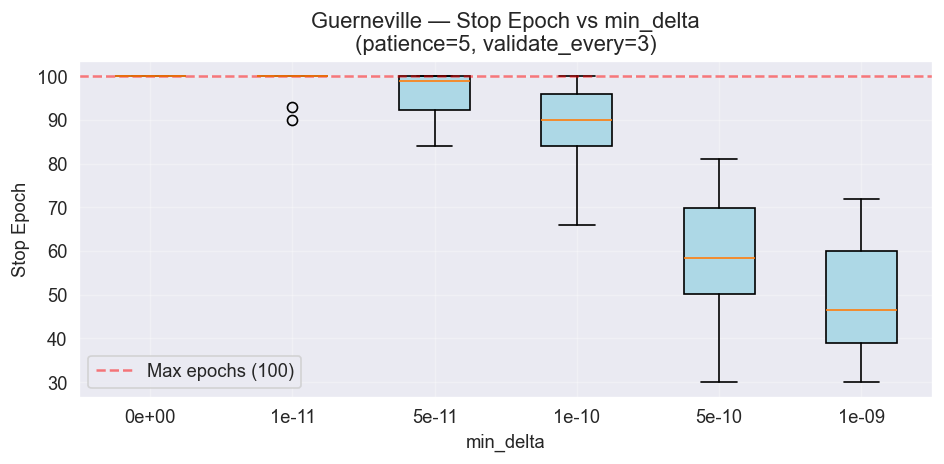

In [9]:
for basin, states in all_es.items():
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # For each delta, collect stop epochs
    delta_labels = []
    median_stops = []
    all_stops = []
    
    for delta in DELTAS_TO_TEST:
        stops = []
        for s in states:
            epochs, losses = extract_loss_history(s['state'])
            if len(epochs) == 0:
                continue
            stop = simulate_early_stop(epochs, losses, 
                                       patience=PATIENCE,
                                       min_delta=delta, 
                                       min_epoch=MIN_EPOCH)
            stops.append(stop if stop else s['final_epoch'])
        
        delta_labels.append(f"{delta:.0e}")
        all_stops.append(stops)
        median_stops.append(np.median(stops))
    
    bp = ax.boxplot(all_stops, labels=delta_labels, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Max epochs (100)')
    ax.set_xlabel('min_delta')
    ax.set_ylabel('Stop Epoch')
    ax.set_title(f"{basin.replace('_', ' ').title()} — Stop Epoch vs min_delta\n"
                 f"(patience={PATIENCE}, validate_every=3)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 2e. Epoch-over-Epoch Improvement Rates

What % improvement does each validation check deliver? Where do diminishing returns kick in?

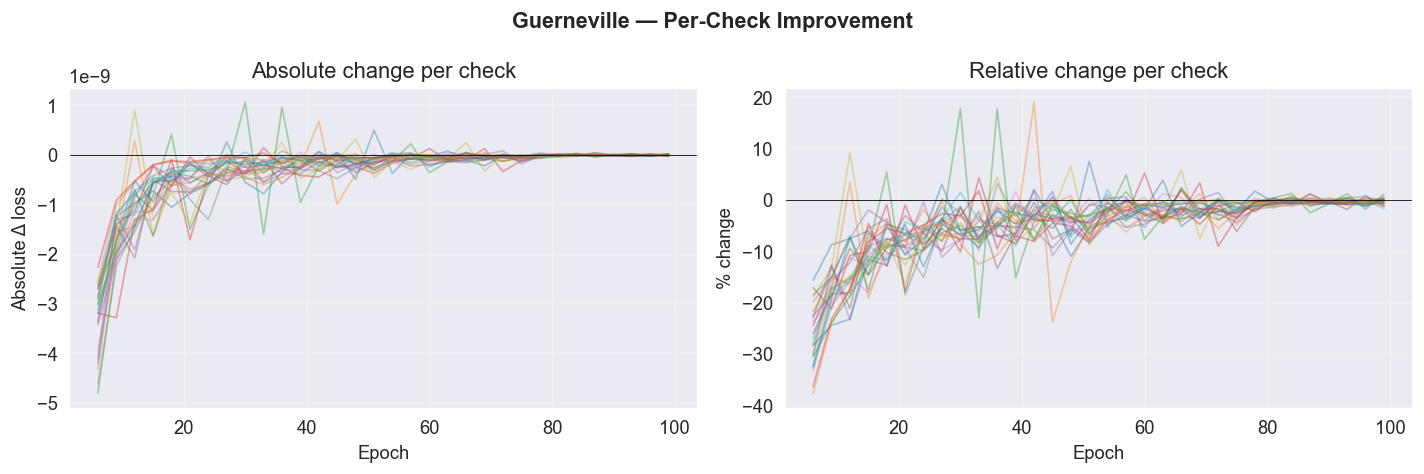

In [10]:
for basin, states in all_es.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{basin.replace('_', ' ').title()} — Per-Check Improvement",
                 fontsize=13, fontweight='bold')
    
    for s in states:
        epochs, losses = extract_loss_history(s['state'])
        if len(epochs) < 2:
            continue
        
        # Absolute delta
        deltas = np.diff(losses)
        mid_epochs = epochs[1:]
        axes[0].plot(mid_epochs, deltas, alpha=0.4, linewidth=1)
        
        # Percent improvement
        pct = 100.0 * deltas / losses[:-1]
        axes[1].plot(mid_epochs, pct, alpha=0.4, linewidth=1)
    
    axes[0].axhline(0, color='black', linewidth=0.5)
    axes[0].set_ylabel('Absolute Δ loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_title('Absolute change per check')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].axhline(0, color='black', linewidth=0.5)
    axes[1].set_ylabel('% change')
    axes[1].set_xlabel('Epoch')
    axes[1].set_title('Relative change per check')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

---
## 3. TensorBoard Loss Curves — Train vs Validation

Load full train + validation curves from TB event files.  
Note: training loss > validation loss is expected due to **output_dropout=0.4** (dropout active during training, off during validation).

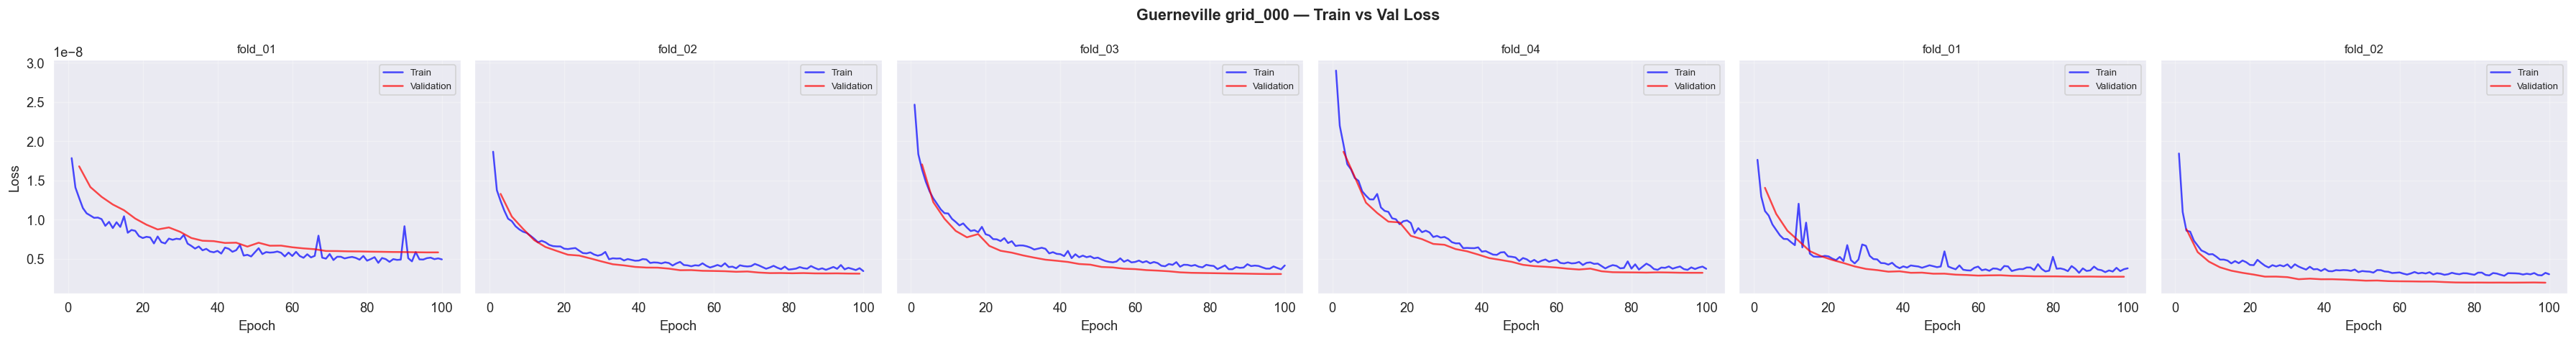

In [11]:
for basin, states in all_es.items():
    # Pick one representative grid combo (grid_000)
    grid_000 = [s for s in states if '_grid_000' in s['grid']]
    if not grid_000:
        continue
    
    n_folds = len(grid_000)
    fig, axes = plt.subplots(1, n_folds, figsize=(5 * n_folds, 4), sharey=True, squeeze=False)
    fig.suptitle(f"{basin.replace('_', ' ').title()} grid_000 — Train vs Val Loss",
                 fontsize=13, fontweight='bold')
    
    for ax, s in zip(axes[0], grid_000):
        # Navigate to the fold dir, then find testing_run_*
        fold_dir = s['path'].parent.parent  # up from testing_run_*/early_stopper_state.pt
        nh_dirs = sorted(fold_dir.glob("testing_run_*"))
        if not nh_dirs:
            continue
        
        tb = extract_losses_from_tensorboard(nh_dirs[-1])
        
        if tb['train_loss']:
            te, tl = zip(*tb['train_loss'])
            ax.plot(te, tl, 'b-', alpha=0.7, linewidth=1.5, label='Train')
        if tb['valid_loss']:
            ve, vl = zip(*tb['valid_loss'])
            ax.plot(ve, vl, 'r-', alpha=0.7, linewidth=1.5, label='Validation')
        
        ax.set_title(s['fold'], fontsize=10)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    axes[0][0].set_ylabel('Loss')
    plt.tight_layout()
    plt.show()

---
## 4. LR Schedule Impact

The fixed LR schedule drops at epoch 50 (0.01→0.005) and 75 (0.005→0.001).  
Does the epoch 75 drop give the model a "second wind" that extends training?

In [12]:
for basin, states in all_es.items():
    print(f"\n{basin.upper()} — Loss improvement by LR regime")
    print("-" * 60)
    
    for s in states[:4]:  # first 4 folds
        epochs, losses = extract_loss_history(s['state'])
        if len(epochs) < 10:
            continue
        
        # Segment by LR schedule: [0-49], [50-74], [75-100]
        segments = [
            ('LR=0.010 (ep 0-49)', (epochs >= 3) & (epochs < 50)),
            ('LR=0.005 (ep 50-74)', (epochs >= 50) & (epochs < 75)),
            ('LR=0.001 (ep 75+)', (epochs >= 75)),
        ]
        
        grid_label = s['grid'].split('_grid_')[-1]
        print(f"\n  grid_{grid_label}/{s['fold']}:")
        
        for label, mask in segments:
            seg_losses = losses[mask]
            if len(seg_losses) >= 2:
                total_drop = seg_losses[0] - seg_losses[-1]
                pct_drop = 100.0 * total_drop / seg_losses[0]
                print(f"    {label}: {seg_losses[0]:.3e} → {seg_losses[-1]:.3e} "
                      f"({pct_drop:+.1f}%)")


GUERNEVILLE — Loss improvement by LR regime
------------------------------------------------------------

  grid_000/fold_01:
    LR=0.010 (ep 0-49): 1.678e-08 → 6.553e-09 (+60.9%)
    LR=0.005 (ep 50-74): 7.044e-09 → 5.982e-09 (+15.1%)
    LR=0.001 (ep 75+): 5.944e-09 → 5.816e-09 (+2.2%)

  grid_000/fold_02:
    LR=0.010 (ep 0-49): 1.327e-08 → 3.743e-09 (+71.8%)
    LR=0.005 (ep 50-74): 3.542e-09 → 3.246e-09 (+8.4%)
    LR=0.001 (ep 75+): 3.175e-09 → 3.105e-09 (+2.2%)

  grid_000/fold_03:
    LR=0.010 (ep 0-49): 1.703e-08 → 4.252e-09 (+75.0%)
    LR=0.005 (ep 50-74): 3.958e-09 → 3.272e-09 (+17.3%)
    LR=0.001 (ep 75+): 3.211e-09 → 3.058e-09 (+4.8%)

  grid_000/fold_04:
    LR=0.010 (ep 0-49): 1.864e-08 → 4.607e-09 (+75.3%)
    LR=0.005 (ep 50-74): 4.229e-09 → 3.409e-09 (+19.4%)
    LR=0.001 (ep 75+): 3.289e-09 → 3.215e-09 (+2.3%)


---
## 5. Findings & Decisions

*To be filled after running all cells and reviewing results.*

**Questions to answer:**
1. What `min_delta` value would stop training at the right epoch?
2. Should we reduce patience from 5 to 3?
3. Should we validate every epoch instead of every 3?
4. Or: just cap grid search epochs at 50-60 and keep 100 for final training?
5. Does the LR drop at epoch 75 justify running past epoch 60?